# Quantum BCH $[[15,7,3]]$ Code

## 1. Introduction
The $[[15, 7, 3]]$ Quantum Bose-Chaudhuri-Hocquenghem (BCH) code is a foundational example of a high-rate quantum error-correcting code. It belongs to the family of cyclic CSS codes and is constructed using the classical $[15, 11, 3]$ Hamming code.

The most notable feature of this code is its **Code Rate ($k/n$)**. While the Steane code encodes 1 logical qubit into 7 physical qubits (rate $\approx 0.14$), the $[[15, 7, 3]]$ BCH code encodes **7 logical qubits** into 15 physical qubits (rate $\approx 0.47$). This high density makes algebraic block codes highly desirable for resource-efficient fault-tolerant architectures.

### 1.1 The Parity Check Matrix
The stabilizer generators are defined by the parity check matrix of the classical $[15, 11, 3]$ code. This matrix $H$ is a $4 \times 15$ binary matrix where the $j$-th column is simply the binary representation of the integer $j$.

$$
H = \begin{pmatrix} 
1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 \\
0 & 1 & 1 & 0 & 0 & 1 & 1 & 0 & 0 & 1 & 1 & 0 & 0 & 1 & 1 \\
0 & 0 & 0 & 1 & 1 & 1 & 1 & 0 & 0 & 0 & 0 & 1 & 1 & 1 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1
\end{pmatrix}
$$

Because all rows have an even weight of 8, and the overlap between any two rows is exactly 4, the matrix is self-orthogonal ($H H^T = 0 \pmod 2$). This perfect orthogonality satisfies the CSS condition, allowing us to use this identical $4 \times 15$ matrix for both $X$-stabilizers and $Z$-stabilizers.



---

## 2. Qiskit Implementation
This implementation builds a 23-qubit system (15 Data + 8 Ancilla). The decoding process leverages the mathematical synergy of the $H$ matrix: **the binary value of the measured syndrome points directly to the index of the faulty qubit.**

In [1]:
%pip install numpy==1.26.4 scipy==1.12.0

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from scipy.optimize import fsolve

print("Imports successful")


Note: you may need to restart the kernel to use updated packages.
Imports successful


In [2]:
class QuantumBCH15:
    def __init__(self):
        # 15 Data Qubits
        self.data = QuantumRegister(15, name='data')

        # 8 Ancilla Qubits (4 for Z-checks, 4 for X-checks)
        self.anc = QuantumRegister(8, name='anc')

        # Classical Registers for Syndromes
        self.sz = ClassicalRegister(4, name='sz') # Z-syndromes (detect X flips)
        self.sx = ClassicalRegister(4, name='sx') # X-syndromes (detect Z flips)

        # Final readout
        self.out = ClassicalRegister(15, name='readout')

        self.qc = QuantumCircuit(self.data, self.anc, self.sz, self.sx, self.out)

    def encode_logical_zero(self):
        r"""
        Encodes |0>^(\otimes 7) into the logical CSS state.
        We prepare the uniform superposition of the dual code C^\perp.
        The power-of-2 columns (1, 2, 4, 8) form the basis generators.
        """
        # Put the basis generator qubits into |+>
        # Qubit indices (0-based) for cols 1, 2, 4, 8 are 0, 1, 3, 7
        generators = [0, 1, 3, 7]
        self.qc.h([self.data[q] for q in generators])

        # Entangle the remaining qubits based on their binary column index
        # For any column C, we CNOT from the generators that sum to C
        for col in range(1, 16):
            q_idx = col - 1
            if q_idx in generators:
                continue

            # Binary breakdown of the column index
            if col & 1: self.qc.cx(self.data[0], self.data[q_idx]) # 1
            if col & 2: self.qc.cx(self.data[1], self.data[q_idx]) # 2
            if col & 4: self.qc.cx(self.data[3], self.data[q_idx]) # 4
            if col & 8: self.qc.cx(self.data[7], self.data[q_idx]) # 8

        self.qc.barrier(label='Encoded')

    def measure_syndromes(self):
        """
        Non-destructive measurement of the 8 stabilizers.
        """
        # Z-Checks (Detect X errors)
        # Row 1 (LSB): Alternating bits (cols 1, 3, 5...)
        for q in [0, 2, 4, 6, 8, 10, 12, 14]: self.qc.cx(self.data[q], self.anc[0])
        # Row 2: (cols 2, 3, 6, 7...)
        for q in [1, 2, 5, 6, 9, 10, 13, 14]: self.qc.cx(self.data[q], self.anc[1])
        # Row 3: (cols 4, 5, 6, 7...)
        for q in [3, 4, 5, 6, 11, 12, 13, 14]: self.qc.cx(self.data[q], self.anc[2])
        # Row 4 (MSB): (cols 8, 9, 10...)
        for q in [7, 8, 9, 10, 11, 12, 13, 14]: self.qc.cx(self.data[q], self.anc[3])

        # X-Checks (Detect Z errors)
        self.qc.h(self.anc[4:8])

        for q in [0, 2, 4, 6, 8, 10, 12, 14]: self.qc.cx(self.anc[4], self.data[q])
        for q in [1, 2, 5, 6, 9, 10, 13, 14]: self.qc.cx(self.anc[5], self.data[q])
        for q in [3, 4, 5, 6, 11, 12, 13, 14]: self.qc.cx(self.anc[6], self.data[q])
        for q in [7, 8, 9, 10, 11, 12, 13, 14]: self.qc.cx(self.anc[7], self.data[q])

        self.qc.h(self.anc[4:8])

        # Measurements
        self.qc.measure(self.anc[0:4], self.sz)
        self.qc.measure(self.anc[4:8], self.sx)
        self.qc.barrier(label='Syndrome Extracted')

    def apply_correction(self):
        """
        Applies dynamic correction. The syndrome directly matches the 1-based
        column index
        """
        # Correct X Errors using Z-syndrome (Values 1 to 15)
        for i in range(1, 16):
            with self.qc.if_test((self.sz, i)):
                self.qc.x(self.data[i-1])

        # Correct Z Errors using X-syndrome (Values 1 to 15)
        for i in range(1, 16):
            with self.qc.if_test((self.sx, i)):
                self.qc.z(self.data[i-1])

        self.qc.barrier(label='Corrected')

    def decode_and_verify(self):
        r"""
        Uncomputes the encoding sequence. If correct, returns to |0>^{times 15}
        """
        generators = [0, 1, 3, 7]

        # Uncompute in reverse (though CNOTs commute here)
        for col in range(15, 0, -1):
            q_idx = col - 1
            if q_idx in generators:
                continue

            if col & 8: self.qc.cx(self.data[7], self.data[q_idx])
            if col & 4: self.qc.cx(self.data[3], self.data[q_idx])
            if col & 2: self.qc.cx(self.data[1], self.data[q_idx])
            if col & 1: self.qc.cx(self.data[0], self.data[q_idx])

        self.qc.h([self.data[q] for q in generators])
        self.qc.measure(self.data, self.out)

        return self.qc


Injecting X error on Qubit 5...


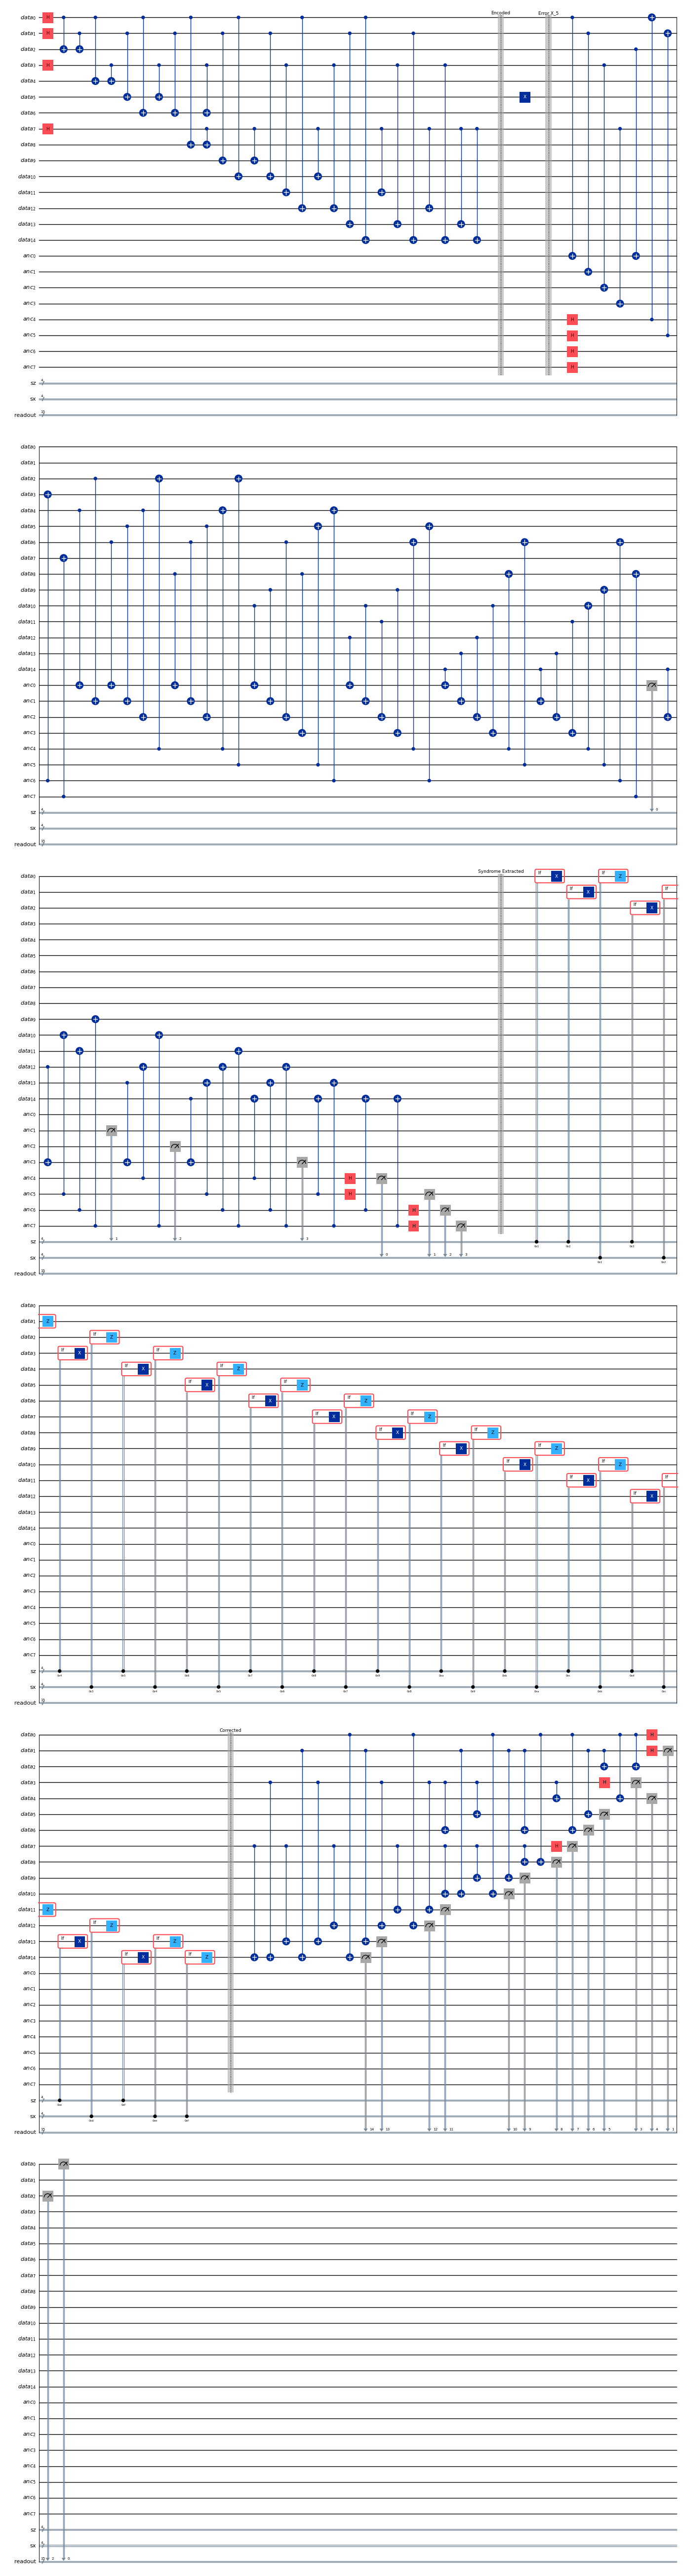

In [3]:
bch_demo = QuantumBCH15()
bch_demo.encode_logical_zero()

# Inject a manual error for demonstration (e.g., X error on Qubit 5)
print("Injecting X error on Qubit 5...")
bch_demo.qc.x(bch_demo.data[5])
bch_demo.qc.barrier(label='Error X_5')

# Complete the cycle
bch_demo.measure_syndromes()
bch_demo.apply_correction()
bch_circ = bch_demo.decode_and_verify()

# Draw the circuit
# scale=0.5 is necessary here for fitting screen
display(bch_circ.draw('mpl', fold=40, scale=0.5))


---

## 3. Performance Simulation
To evaluate the $[[15,7,3]]$ code, we inject independent depolarizing noise ($X$, $Y$, or $Z$) on all 15 data qubits. 

Because it encodes 7 logical qubits simultaneously, the definition of a "logical failure" is strict: if **any** of the 7 logical qubits is corrupted, the block fails. The theoretical worst-case failure probability for a 15-qubit block correcting 1 error is:
$$P_{theory} = 1 - (1-p)^{15} - 15p(1-p)^{14}$$

Simulating 8 points for [[15,7,3]] BCH Code...
p=0.0010 -> P_Logical=0.0001
p=0.0021 -> P_Logical=0.0000
p=0.0043 -> P_Logical=0.0013
p=0.0088 -> P_Logical=0.0043
p=0.0181 -> P_Logical=0.0137
p=0.0373 -> P_Logical=0.0572
p=0.0769 -> P_Logical=0.1758
p=0.1585 -> P_Logical=0.4854


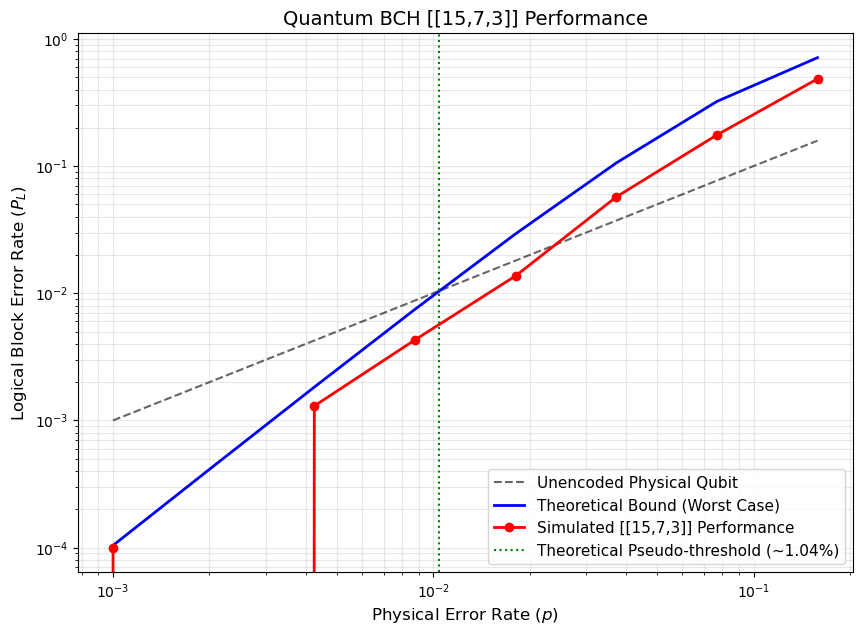

In [4]:
def apply_random_noise(bch_instance, p):
    """Applies depolarizing noise across all 15 physical qubits."""
    for qubit_idx in range(15):
        if np.random.random() < p:
            error_type = np.random.choice(['X', 'Y', 'Z'])
            if error_type == 'X': bch_instance.qc.x(bch_instance.data[qubit_idx])
            elif error_type == 'Y': bch_instance.qc.y(bch_instance.data[qubit_idx])
            elif error_type == 'Z': bch_instance.qc.z(bch_instance.data[qubit_idx])

def run_bch_simulation(p_values, shots_per_point=10000):
    logical_error_rates = []
    backend = AerSimulator(method='stabilizer')

    print(f"Simulating {len(p_values)} points for [[15,7,3]] BCH Code...")
    for p in p_values:
        failures = 0
        circuits = []

        for _ in range(shots_per_point):
            bch = QuantumBCH15()
            bch.encode_logical_zero()
            apply_random_noise(bch, p)
            bch.measure_syndromes()
            bch.apply_correction()
            circuits.append(bch.decode_and_verify())

        result = backend.run(circuits, shots=1, optimization_level=0).result()

        for i in range(shots_per_point):
            counts = result.get_counts(i)
            outcome = list(counts.keys())[0]
            readout = outcome.split(" ")[0]

            # Success means all 15 qubits returned to 0
            if readout != '000000000000000':
                failures += 1

        p_logical = failures / shots_per_point
        logical_error_rates.append(p_logical)
        print(f"p={p:.4f} -> P_Logical={p_logical:.4f}")

    return logical_error_rates

# Define physical error rates
p_phys_samples = np.logspace(-3, -0.8, 8)

# Run simulation
p_log_simulated = run_bch_simulation(p_phys_samples, shots_per_point=10000)

# Calculate Theoretical Bounds
# Worst-case failure: 2 or more errors anywhere in the 15-qubit block
p_theoretical = 1 - (1 - p_phys_samples)**15 - 15 * p_phys_samples * (1 - p_phys_samples)**14

# Plotting
plt.figure(figsize=(10, 7))

plt.loglog(p_phys_samples, p_phys_samples, 'k--', label='Unencoded Physical Qubit', alpha=0.6)
plt.loglog(p_phys_samples, p_theoretical, 'b-', label='Theoretical Bound (Worst Case)', linewidth=2)
plt.loglog(p_phys_samples, p_log_simulated, 'ro-', label='Simulated [[15,7,3]] Performance', linewidth=2)

plt.title('Quantum BCH [[15,7,3]] Performance', fontsize=14)
plt.xlabel('Physical Error Rate ($p$)', fontsize=12)
plt.ylabel('Logical Block Error Rate ($P_L$)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)

# Calculate the exact crossover point for n=15
def bch_theoretical_diff(p):
    return (1 - (1 - p)**15 - 15 * p * (1 - p)**14) - p

exact_bch_crossover = fsolve(bch_theoretical_diff, 0.01)[0]

plt.axvline(x=exact_bch_crossover, color='green', linestyle=':',
            label=f'Theoretical Pseudo-threshold (~{exact_bch_crossover*100:.2f}%)')

plt.legend(fontsize=11)

plt.show()
